In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Bank Customer Churn Prediction.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print(df.dtypes)
print(df.isnull().sum())
print("duplicate ids:", df['customer_id'].duplicated().sum())
print("duplicate rows:", df.duplicated().sum())

for col in ['country', 'gender', 'products_number', 'credit_card', 'active_member', 'tenure']:
    print(col, ":", df[col].nunique(), "unique ->", sorted(df[col].unique()))

print(df['churn'].value_counts())
print((df['churn'].value_counts(normalize=True) * 100).round(2), "%")

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64
duplicate ids: 0
duplicate rows: 0
country : 3 unique -> ['France', 'Germany', 'Spain']
gender : 2 unique -> ['Female', 'Male']
products_number : 4 unique -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
credit_card : 2 unique -> [np.int64(0), np.int64(1)]
active_member : 2 unique -> [np.int64(0), np.int64(1)]
tenure : 11 unique -> [np.int64(0), np.int64(1), np.in

In [ ]:
df = df.drop(columns=['customer_id'])
df.describe()

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


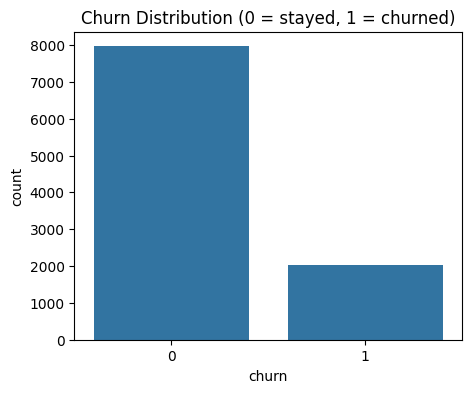

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution (0 = stayed, 1 = churned)')
plt.show()

country
France     16.2
Germany    32.4
Spain      16.7
Name: churn, dtype: float64 %


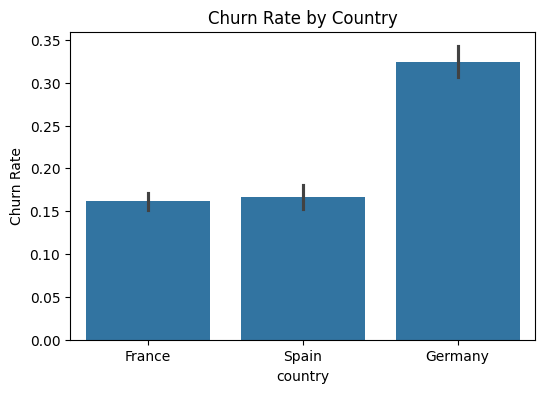

In [ ]:
print(df.groupby('country')['churn'].mean().round(3) * 100, "%")

plt.figure(figsize=(6,4))
sns.barplot(x='country', y='churn', data=df)
plt.title('Churn Rate by Country')
plt.ylabel('Churn Rate')
plt.show()

gender
Female    25.1
Male      16.5
Name: churn, dtype: float64 %


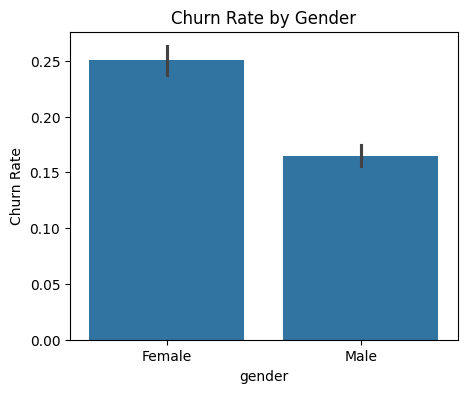

In [ ]:
print(df.groupby('gender')['churn'].mean().round(3) * 100, "%")

plt.figure(figsize=(5,4))
sns.barplot(x='gender', y='churn', data=df)
plt.title('Churn Rate by Gender')
plt.ylabel('Churn Rate')
plt.show()

products_number
1     27.7
2      7.6
3     82.7
4    100.0
Name: churn, dtype: float64 %


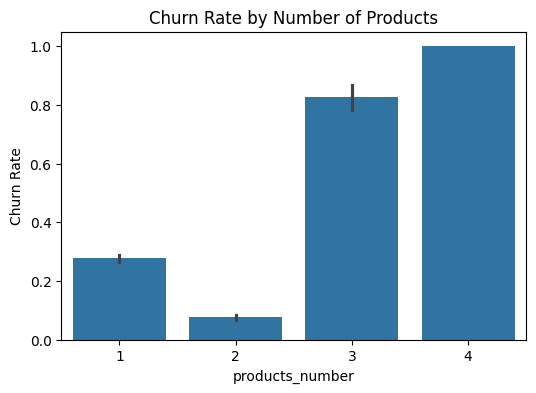

In [ ]:
print(df.groupby('products_number')['churn'].mean().round(3) * 100, "%")

plt.figure(figsize=(6,4))
sns.barplot(x='products_number', y='churn', data=df)
plt.title('Churn Rate by Number of Products')
plt.ylabel('Churn Rate')
plt.show()

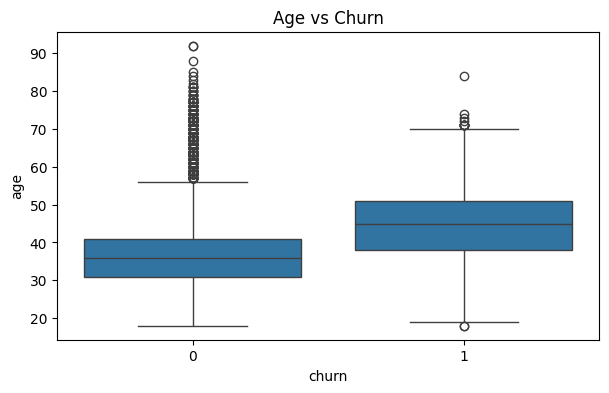

churn
0    37.4
1    44.8
Name: age, dtype: float64


In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x='churn', y='age', data=df)
plt.title('Age vs Churn')
plt.show()

print(df.groupby('churn')['age'].mean().round(1))

active_member
0    26.9
1    14.3
Name: churn, dtype: float64 %


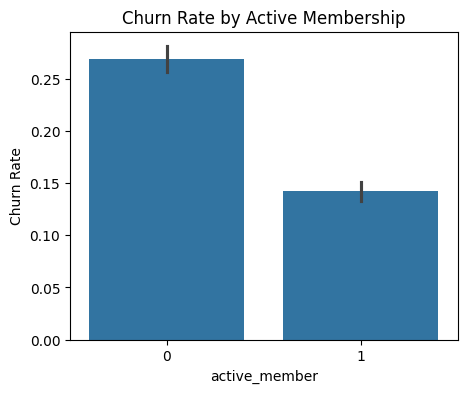

In [ ]:
print(df.groupby('active_member')['churn'].mean().round(3) * 100, "%")

plt.figure(figsize=(5,4))
sns.barplot(x='active_member', y='churn', data=df)
plt.title('Churn Rate by Active Membership')
plt.ylabel('Churn Rate')
plt.show()

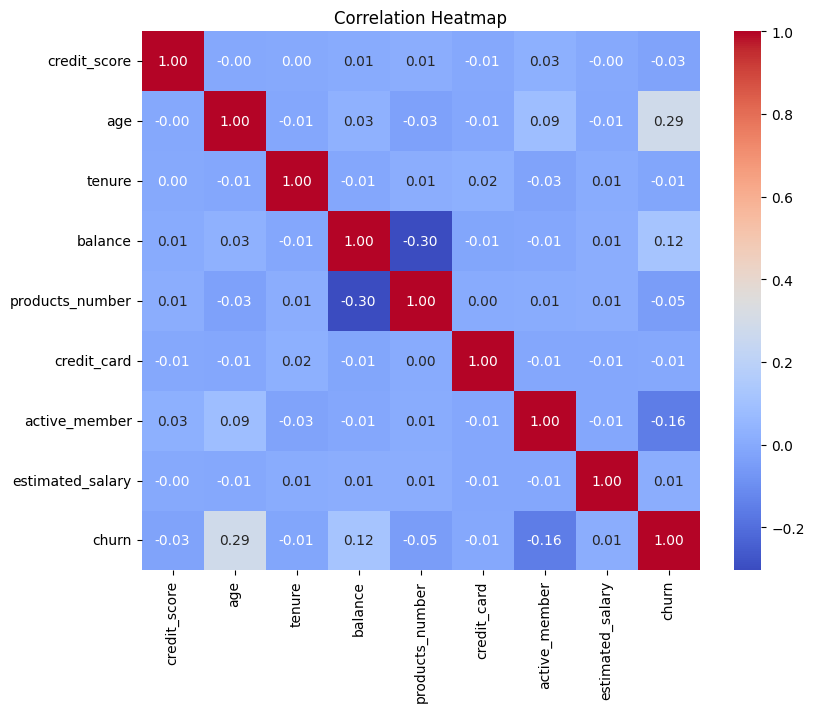

In [ ]:
plt.figure(figsize=(9,7))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['country'], drop_first=True)
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['country_Germany'] = df['country_Germany'].astype(int)
df['country_Spain'] = df['country_Spain'].astype(int)
df.head()

,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1


In [ ]:
df['balance_per_product'] = df['balance'] / df['products_number']
df['is_zero_balance'] = (df['balance'] == 0).astype(int)
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 100], labels=[0, 1, 2, 3]).astype(int)
df['tenure_active'] = df['tenure'] * df['active_member']
df['credit_score_bin'] = pd.cut(df['credit_score'], bins=[0, 580, 670, 740, 850], labels=[0, 1, 2, 3]).astype(int)

print("Shape after feature engineering:", df.shape)
df.head()

Shape after feature engineering: (10000, 17)


,credit_score,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,balance_per_product,is_zero_balance,age_group,tenure_active,credit_score_bin
0,619,1,42,2,0.00,1,1,1,101348.88,1,0,0,0.000000,1,1,2,1
1,608,1,41,1,83807.86,1,0,1,112542.58,0,0,1,83807.860000,0,1,1,1
2,502,1,42,8,159660.80,3,1,0,113931.57,1,0,0,53220.266667,0,1,0,0
3,699,1,39,1,0.00,2,0,0,93826.63,0,0,0,0.000000,1,1,0,2
4,850,1,43,2,125510.82,1,1,1,79084.10,0,0,1,125510.820000,0,1,2,3


In [ ]:
weak_features = ['credit_card', 'credit_score', 'tenure', 'country_Spain', 'credit_score_bin']

df = df.drop(columns=weak_features)

print("Final shape:", df.shape)
print("Final features:", [c for c in df.columns if c != 'churn'])

Final shape: (10000, 12)
Final features: ['gender', 'age', 'balance', 'products_number', 'active_member', 'estimated_salary', 'country_Germany', 'balance_per_product', 'is_zero_balance', 'age_group', 'tenure_active']


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Train churn %:", y_train.mean().round(3))
print("Val churn %:", y_val.mean().round(3))
print("Test churn %:", y_test.mean().round(3))

Train: (7000, 11) Val: (1500, 11) Test: (1500, 11)
Train churn %: 0.204
Val churn %: 0.204
Test churn %: 0.203


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling done on", X_train_scaled.shape[1], "features")

Scaling done on 11 features


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

scale_pos_weight: 3.91


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
log_reg_scores = cross_validate(log_reg, X_train_scaled, y_train, cv=cv, scoring=scoring)

print("Logistic Regression - 5 Fold CV Results")
for metric in scoring:
    scores = log_reg_scores[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression - 5 Fold CV Results
accuracy: 0.7023 (+/- 0.0095)
precision: 0.3743 (+/- 0.0111)
recall: 0.6858 (+/- 0.0156)
f1: 0.4842 (+/- 0.0122)
roc_auc: 0.7564 (+/- 0.0055)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf_scores = cross_validate(rf, X_train_scaled, y_train, cv=cv, scoring=scoring)

print("Random Forest - 5 Fold CV Results")
for metric in scoring:
    scores = rf_scores[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Random Forest - 5 Fold CV Results
accuracy: 0.8477 (+/- 0.0100)
precision: 0.6932 (+/- 0.0334)
recall: 0.4523 (+/- 0.0379)
f1: 0.5469 (+/- 0.0355)
roc_auc: 0.8319 (+/- 0.0122)


In [ ]:
!pip install xgboost -q
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss'
)
xgb_scores = cross_validate(xgb, X_train_scaled, y_train, cv=cv, scoring=scoring)

print("XGBoost - 5 Fold CV Results")
for metric in scoring:
    scores = xgb_scores[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

XGBoost - 5 Fold CV Results
accuracy: 0.8071 (+/- 0.0088)
precision: 0.5203 (+/- 0.0165)
recall: 0.6907 (+/- 0.0256)
f1: 0.5933 (+/- 0.0172)
roc_auc: 0.8441 (+/- 0.0083)


In [ ]:
from sklearn.svm import SVC

svm = SVC(class_weight='balanced', probability=True, random_state=42)
svm_scores = cross_validate(svm, X_train_scaled, y_train, cv=cv, scoring=scoring)

print("SVM - 5 Fold CV Results")
for metric in scoring:
    scores = svm_scores[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std():.4f})")

SVM - 5 Fold CV Results
accuracy: 0.7854 (+/- 0.0102)
precision: 0.4833 (+/- 0.0162)
recall: 0.7468 (+/- 0.0230)
f1: 0.5865 (+/- 0.0135)
roc_auc: 0.8458 (+/- 0.0036)


In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'Accuracy': [log_reg_scores['test_accuracy'].mean(), rf_scores['test_accuracy'].mean(), xgb_scores['test_accuracy'].mean(), svm_scores['test_accuracy'].mean()],
    'Precision': [log_reg_scores['test_precision'].mean(), rf_scores['test_precision'].mean(), xgb_scores['test_precision'].mean(), svm_scores['test_precision'].mean()],
    'Recall': [log_reg_scores['test_recall'].mean(), rf_scores['test_recall'].mean(), xgb_scores['test_recall'].mean(), svm_scores['test_recall'].mean()],
    'F1': [log_reg_scores['test_f1'].mean(), rf_scores['test_f1'].mean(), xgb_scores['test_f1'].mean(), svm_scores['test_f1'].mean()],
    'ROC_AUC': [log_reg_scores['test_roc_auc'].mean(), rf_scores['test_roc_auc'].mean(), xgb_scores['test_roc_auc'].mean(), svm_scores['test_roc_auc'].mean()],
})
comparison = comparison.round(4).sort_values('F1', ascending=False)
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,XGBoost,0.8071,0.5203,0.6907,0.5933,0.8441
3,SVM,0.7854,0.4833,0.7468,0.5865,0.8458
1,Random Forest,0.8477,0.6932,0.4523,0.5469,0.8319
0,Logistic Regression,0.7023,0.3743,0.6858,0.4842,0.7564


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

xgb_base = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist, n_iter=50,
    scoring='roc_auc', cv=cv, random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train_scaled, y_train)

print("Best ROC-AUC (CV):", random_search.best_score_.round(4))
print("Best params:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best ROC-AUC (CV): 0.8607
Best params: {'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_params = random_search.best_params_

final_model = XGBClassifier(**best_params, scale_pos_weight=scale_pos_weight, random_state=42, eval_metric='logloss')
final_model.fit(X_train_scaled, y_train)

y_val_pred = final_model.predict(X_val_scaled)
y_val_proba = final_model.predict_proba(X_val_scaled)[:, 1]

print("=== Classification Report (Validation, threshold=0.5) ===")
print(classification_report(y_val, y_val_pred, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", roc_auc_score(y_val, y_val_proba).round(4))

=== Classification Report (Validation, threshold=0.5) ===
              precision    recall  f1-score   support

    No Churn       0.94      0.82      0.88      1194
       Churn       0.53      0.79      0.64       306

    accuracy                           0.82      1500
   macro avg       0.74      0.81      0.76      1500
weighted avg       0.86      0.82      0.83      1500

ROC-AUC: 0.8947


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    preds = (y_val_proba >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'accuracy': accuracy_score(y_val, preds),
        'precision': precision_score(y_val, preds),
        'recall': recall_score(y_val, preds),
        'f1': f1_score(y_val, preds)
    })

threshold_df = pd.DataFrame(results).round(4)
threshold_df

,threshold,accuracy,precision,recall,f1
0,0.10,0.3560,0.2393,0.9902,0.3855
1,0.15,0.4593,0.2723,0.9869,0.4269
2,0.20,0.5427,0.3057,0.9771,0.4657
3,0.25,0.6120,0.3406,0.9641,0.5034
4,0.30,0.6747,0.3809,0.9510,0.5439
5,0.35,0.7087,0.4047,0.9085,0.5599
6,0.40,0.7493,0.4422,0.8758,0.5877
7,0.45,0.7827,0.4814,0.8464,0.6137
8,0.50,0.8153,0.5317,0.7941,0.6370
9,0.55,0.8333,0.5697,0.7484,0.6469


=== FINAL TEST SET RESULTS ===
              precision    recall  f1-score   support

    No Churn       0.92      0.89      0.90      1195
       Churn       0.61      0.68      0.64       305

    accuracy                           0.85      1500
   macro avg       0.76      0.78      0.77      1500
weighted avg       0.85      0.85      0.85      1500

ROC-AUC: 0.8762


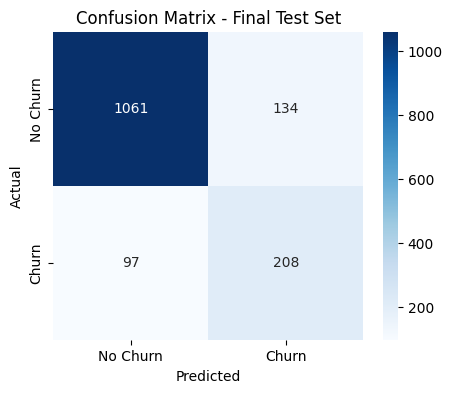

In [ ]:
FINAL_THRESHOLD = 0.60

y_test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred = (y_test_proba >= FINAL_THRESHOLD).astype(int)

print("=== FINAL TEST SET RESULTS ===")
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", roc_auc_score(y_test, y_test_proba).round(4))

cm_test = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.title('Confusion Matrix - Final Test Set')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

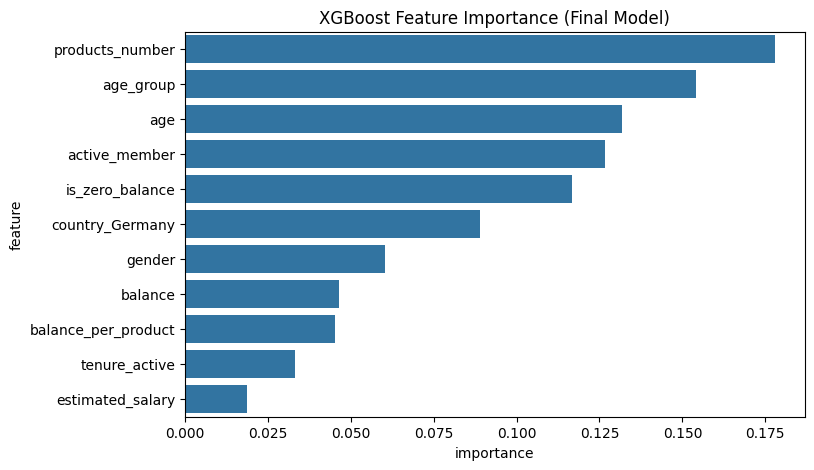

,feature,importance
3,products_number,0.178029
9,age_group,0.154070
1,age,0.131751
4,active_member,0.126711
8,is_zero_balance,0.116654
6,country_Germany,0.088839
0,gender,0.060378
2,balance,0.046515
7,balance_per_product,0.045190
10,tenure_active,0.033122


In [ ]:
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x='importance', y='feature', data=importance)
plt.title('XGBoost Feature Importance (Final Model)')
plt.show()

importance

In [ ]:
import joblib

joblib.dump(final_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(list(X_train.columns), 'feature_columns.pkl')

print("Saved: churn_model.pkl, scaler.pkl, feature_columns.pkl")
print("Feature order:", list(X_train.columns))
print("Note: FINAL_THRESHOLD = 0.60 is set manually in the API code, not saved as a file")

Saved: churn_model.pkl, scaler.pkl, feature_columns.pkl
Feature order: ['gender', 'age', 'balance', 'products_number', 'active_member', 'estimated_salary', 'country_Germany', 'balance_per_product', 'is_zero_balance', 'age_group', 'tenure_active']
Note: FINAL_THRESHOLD = 0.60 is set manually in the API code, not saved as a file
